# Executive Exploratory Data Analysis

# 1. Executive Summary

Our analysis establishes a framework for Bitcoin (BTC) positioning by synthesizing structural valuation on the BTC chain with real-time speculative activity on Polymarket. Our findings suggest that a potential “Golden Entry” regime may be defined by the convergence of several signals.

- On-chain active churn: BTC's most favorable accumulation conditions do not occur during periods of extreme outflow but rather in an “active churn” window where net flow is moderate while BTC is relatively undervalued.

- Polymarket event intensity functions more as a risk regime filter than a return predictor, with moderate-to-high activity associated with lower forward drawdown risk.

- Major macro events may act as temporary volatility anchors, reflecting shifts in market attention and uncertainty.

- Trade-level large bets are structurally interesting but do not yet provide stable predictive signals.


# 2. Data Retrieval

In this EDA, we use two main data sources:

- Coin Metrics BTC daily dataset (coinmetrics_btc.csv) for price and on-chain features.

- Polymarket finance & politics Parquet exports (markets, tokens, trades, odds history, event statistics, and summary files) to capture prediction market activity and pricing behavior.

2.1 Coinmetrics

For the Coin Metrics dataset, we convert the time column to timezone-aware UTC timestamps and set it as the index to ensure proper time-series alignment. We restrict the sample period to 2018-01-01 through 2025-12-31 to maintain consistency across datasets. The data is sorted chronologically and verified to have a strictly increasing, unique time index.

Based on PriceUSD, we construct daily returns, log returns, 200-day moving average, relative deviation from the moving average, and drawdown. We also generate forward-looking metrics such as 30-day annualized volatility, forward returns, and forward maximum drawdown. In addition, we apply quintile binning to MVRV and Net Flow to normalize on-chain valuation and capital flow signals for cross-feature comparison.

2.2 Ploymarket

For Markets dataset, we narrow down the vast amount of event to only those macro events that have high relevance to the crypto ecosystem, that includes markets categorized under 'crypto', 'business' and 'politics'. We transform the raw data into daily tim series features to quantify new markets launched daily and sum daily USD volume to identify peaks in capital commitment. We have also calculated the average 'lifecycle' of markets.

For the Odds History dataset, we convert timestamps to daily frequency and restrict the sample to binary outcome markets for consistency. We construct daily probability-based features, including a risk index and volatility measures, and align them with BTC daily data.

For event-level data, we use total volume, market count, and active windows to construct daily event activity indicators (active_event_count, active_volume_sum, active_market_sum). To reduce skewness, we apply a log transformation to volume before merging these features with BTC metrics.

We've also retrieved trades data that are granular high frequency trade logs that can help with identifying participants patterns (institution vs retail) and short term concentrated trend of betting

# 3. General Dataset Overview

3.1 Coinmetrics

The Coin Metrics dataset contains 2,922 daily observations from 2018-01-01 to 2025-12-31. The time index is strictly increasing with no duplicate timestamps, indicating a clean and well-structured time series.

Most core price and on-chain variables have no missing values. Several ReferenceRate columns are entirely empty and are excluded from analysis, while CapMrktEstUSD has partial missing values (~18%) and would require careful handling if used in modeling. Overall, the dataset shows strong completeness for key variables such as price, transaction counts, supply, and valuation metrics.

From 2018 to 2025, BTC experienced multiple market cycles, including a post-2018 decline, a strong 2020–2021 bull market, a sharp 2022 correction, and renewed volatility after 2023. Market capitalization closely mirrors price, as expected. Hashrate, however, shows a more structural upward trend, reflecting long-term network growth despite cyclical price fluctuations.

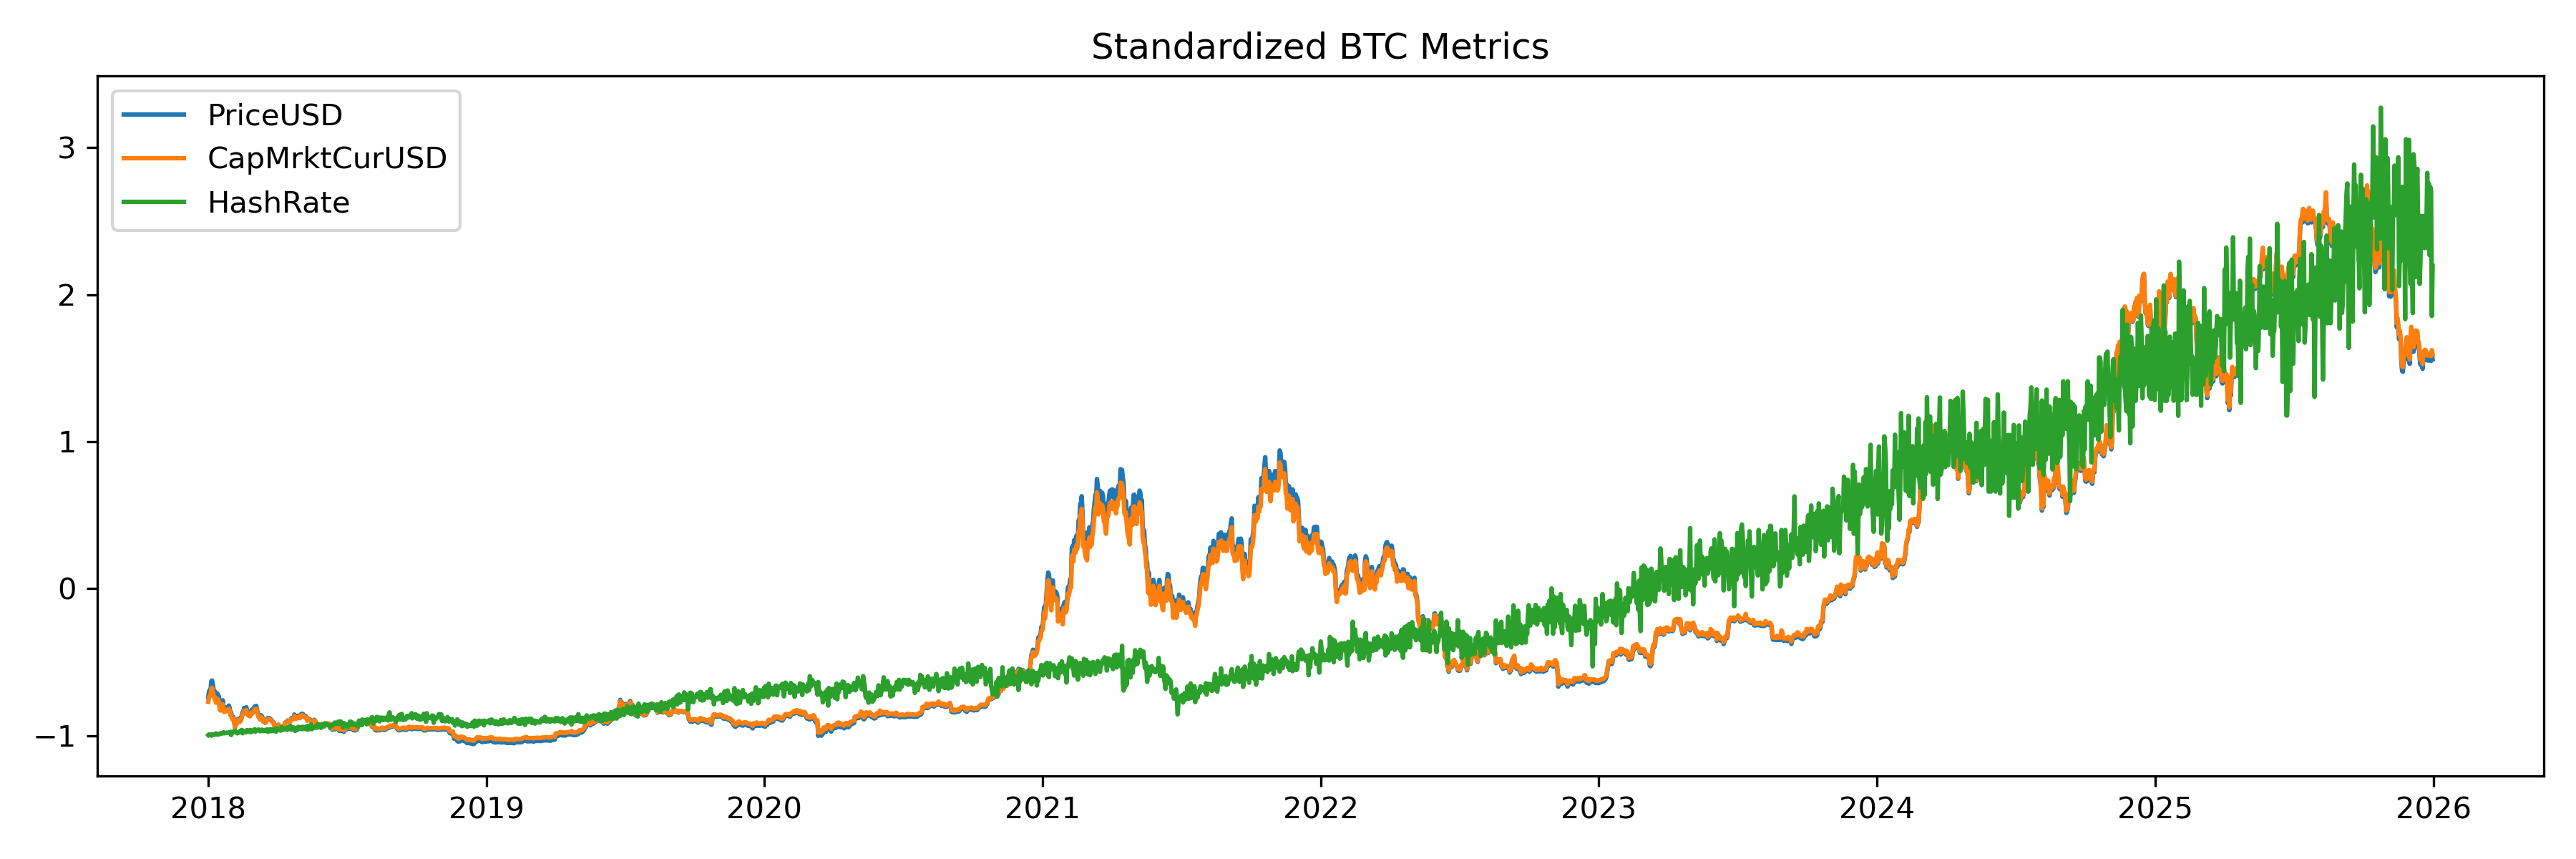

In [7]:
from IPython.display import Image, display
display(Image("plots/Standardized BTC Metrics.png"))

The correlation matrix confirms strong mechanical relationships, such as the near-perfect correlation between price and market capitalization. Exchange inflows and outflows are highly correlated, suggesting that net flow may carry more noise than directional signal. Many on-chain indicators co-move with price across market regimes, while metrics such as active addresses show weaker correlation, potentially offering more independent information. MVRV exhibits moderate correlation with price, consistent with its role as a valuation measure rather than a pure trend indicator.

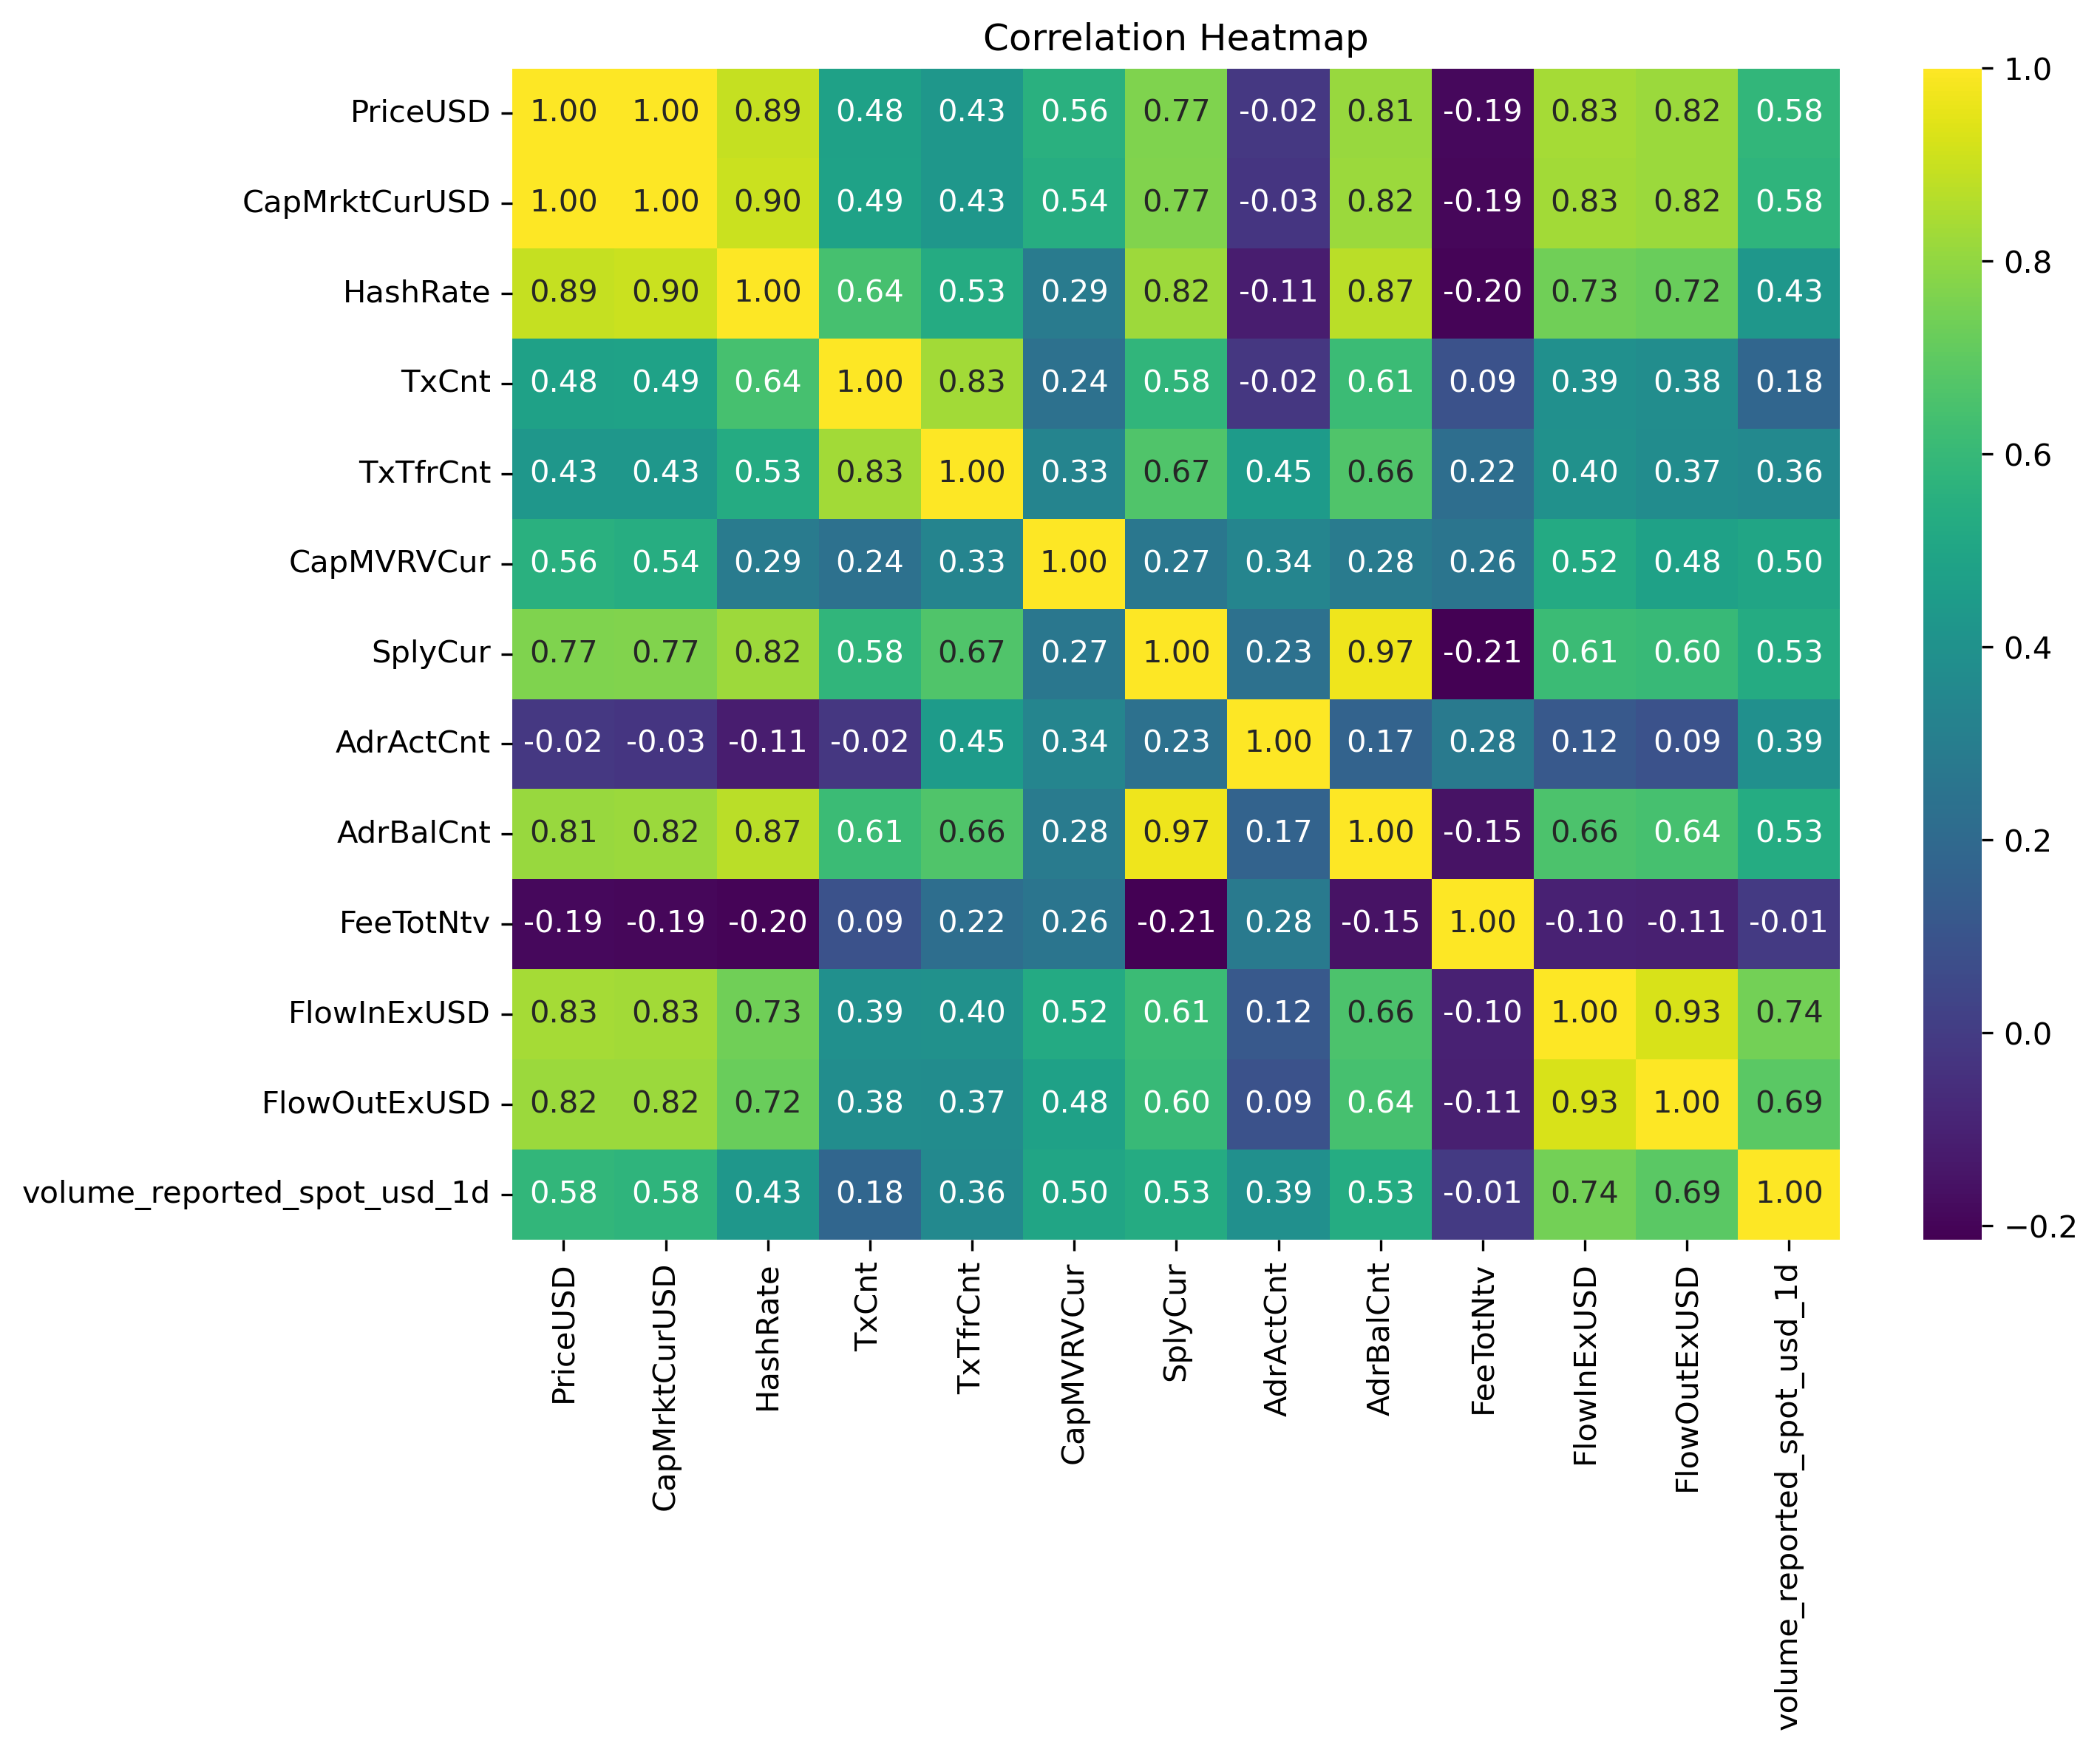

In [19]:
display(Image("plots/correlation_heatmap.png"))

3.2 Ploymarket

3.2.1 Market

This dataset contains structural information of prediction markets, categorized by topics such as politics, business and crypto. The dataset is quite complete. 

We've grouped the top events by event cluster, ordered by total traded volume

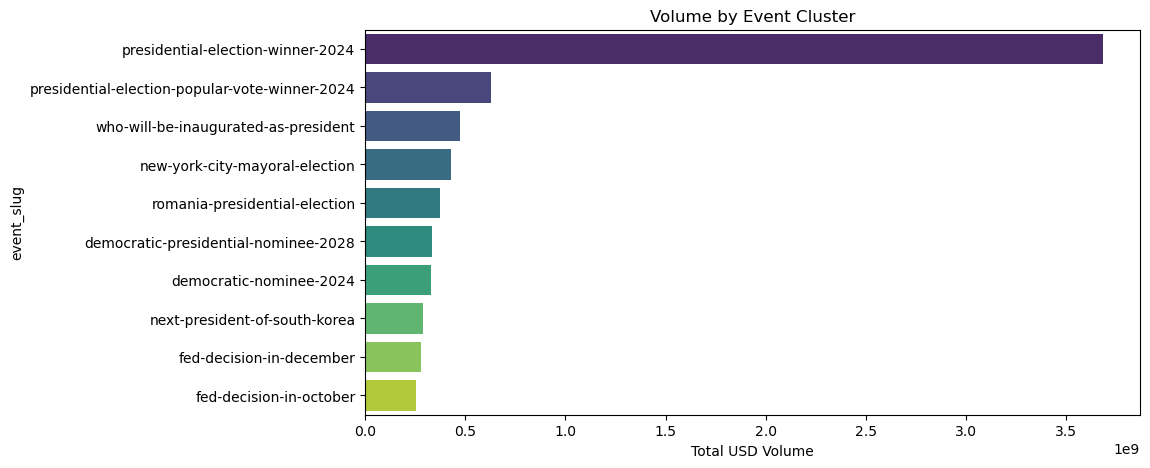

In [8]:
display(Image("plots/VolumeByCluster.png"))

3.2.2 Trades

This dataset captures the granular activity of individual participants, key columns include timestamp, size, side, taker/maker address and market id. price is between 0-1 which is normalized. All trades are at the transaction level. 

3.2.3 Odds History

After processing, the Odds History dataset contains approximately 785,000 daily observations from 2023 to 2026. Key features include daily closing probability, update frequency, short-term probability changes, and rolling volatility. Probabilities tend to cluster around 0.5 on average but move toward extremes as events approach resolution, reflecting changes in market certainty.

3.2.4 Event

The Event dataset is highly skewed: most events have minimal volume, while a small number of macro events dominate total activity. Volume is influenced by both event duration and market count, so raw totals do not directly reflect importance. The largest events are primarily macro-political and policy-related, suggesting potential links to broader risk sentiment.

# 4. Prediction Market Exploration

In this section, we try to understand whether Polymarket data can actually help improve a Bitcoin accumulation strategy. Instead of looking at prediction market data alone, we analyze it together with BTC price, MVRV, exchange net flow, and other on-chain indicators. Our goal is to see whether Polymarket adds any useful information beyond what we already observe from on-chain data.

4.1 On-Chain Baseline

Before introducing Polymarket data, we first analyze on-chain metrics to establish a baseline accumulation framework. By grouping MVRV, exchange net flow, and active address count into quintiles and examining forward 30-day performance, we observe that lower MVRV levels are generally associated with higher future returns, while higher MVRV levels correspond to increased downside risk. Exchange inflows appear to be more informative for risk than for return, as strong inflows are often followed by higher drawdown probability. Active address count shows a non-linear relationship with volatility, where both very low and very high activity levels are linked to elevated risk. 

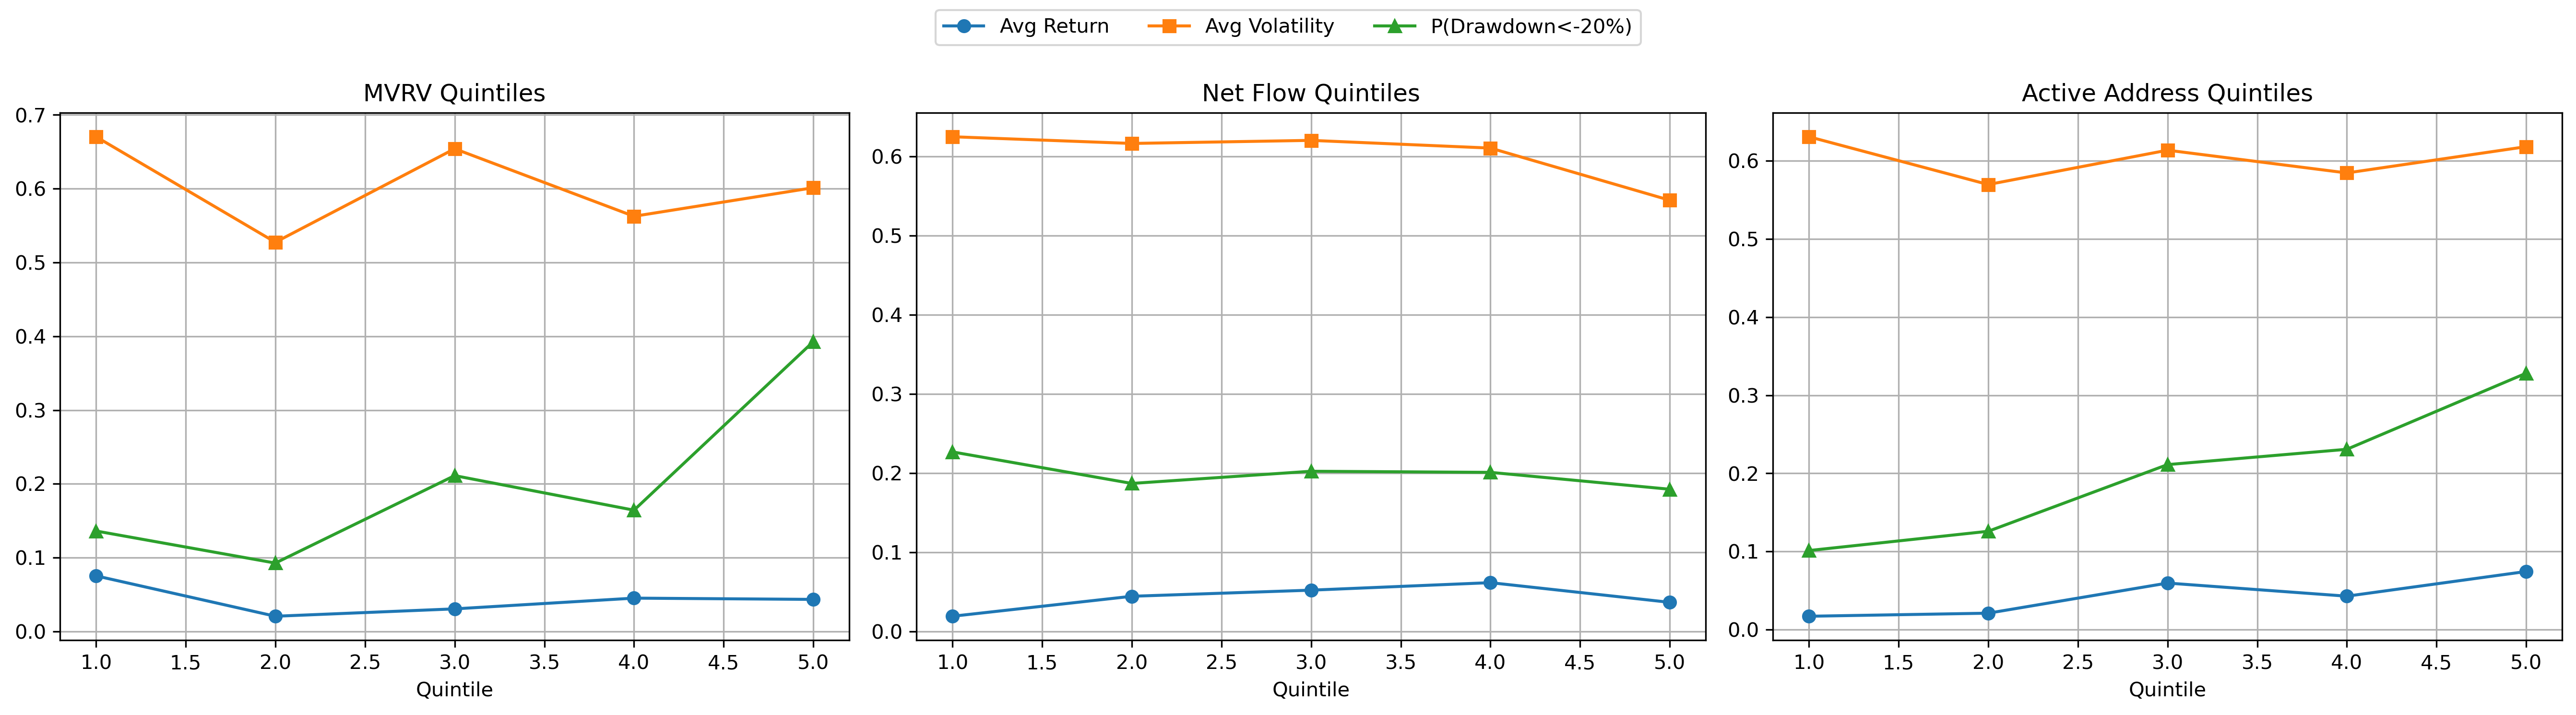

In [14]:
display(Image("plots/Forward_30D_Factor_Comparison.png"))

When combining MVRV and net flow together, the most favorable forward returns occur when BTC is relatively undervalued but net flow remains moderate rather than extreme, suggesting that optimal accumulation may occur during active but stable market conditions rather than during panic-driven outflows.

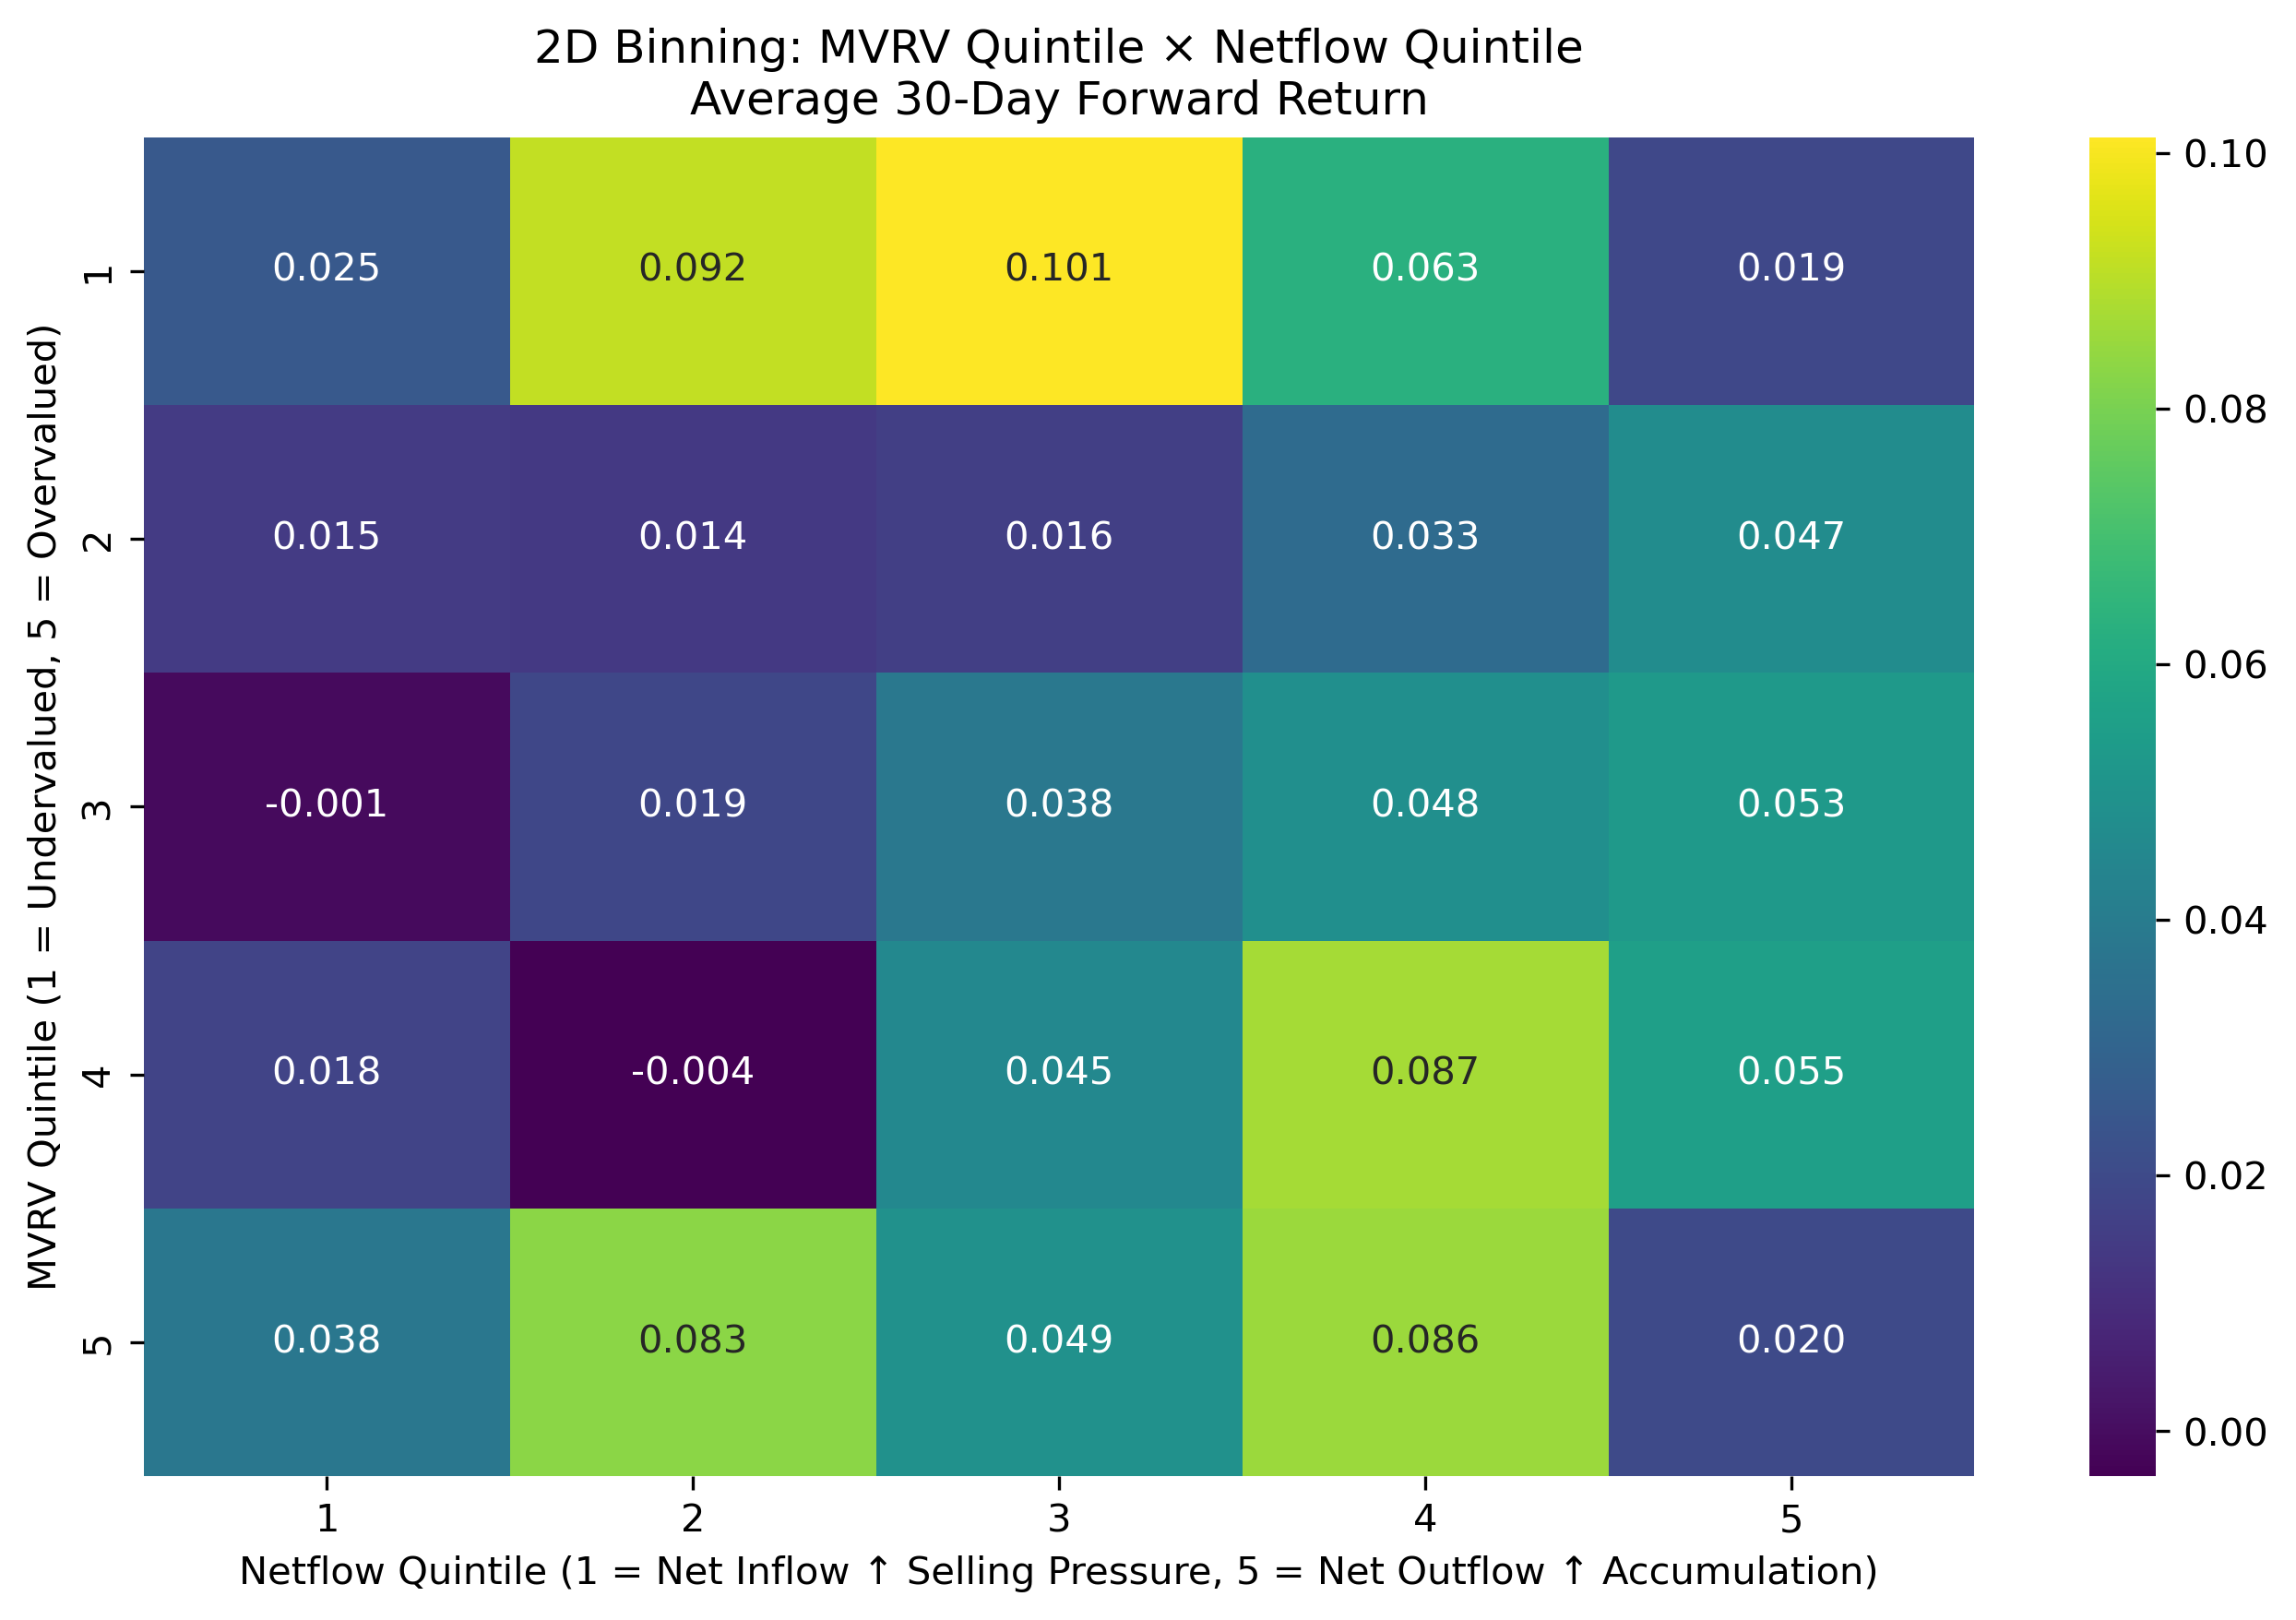

In [13]:
display(Image("plots/2D Binning: MVRV Quintile × Netflow Quintile\nAverage 30-Day Forward Return.png", width=600))

4.2 Event Intensity and Risk Regimes

We then incorporate Polymarket event-level data by constructing daily measures such as active event count and total active event volume. When grouping days by event intensity quintiles, we do not observe a consistent directional pattern in forward 30-day returns. However, a clearer structure emerges when focusing on downside risk. Moderate-to-high event intensity days are associated with a lower probability of experiencing a -20% drawdown in the following 30 days, while days with no event activity show higher downside risk.

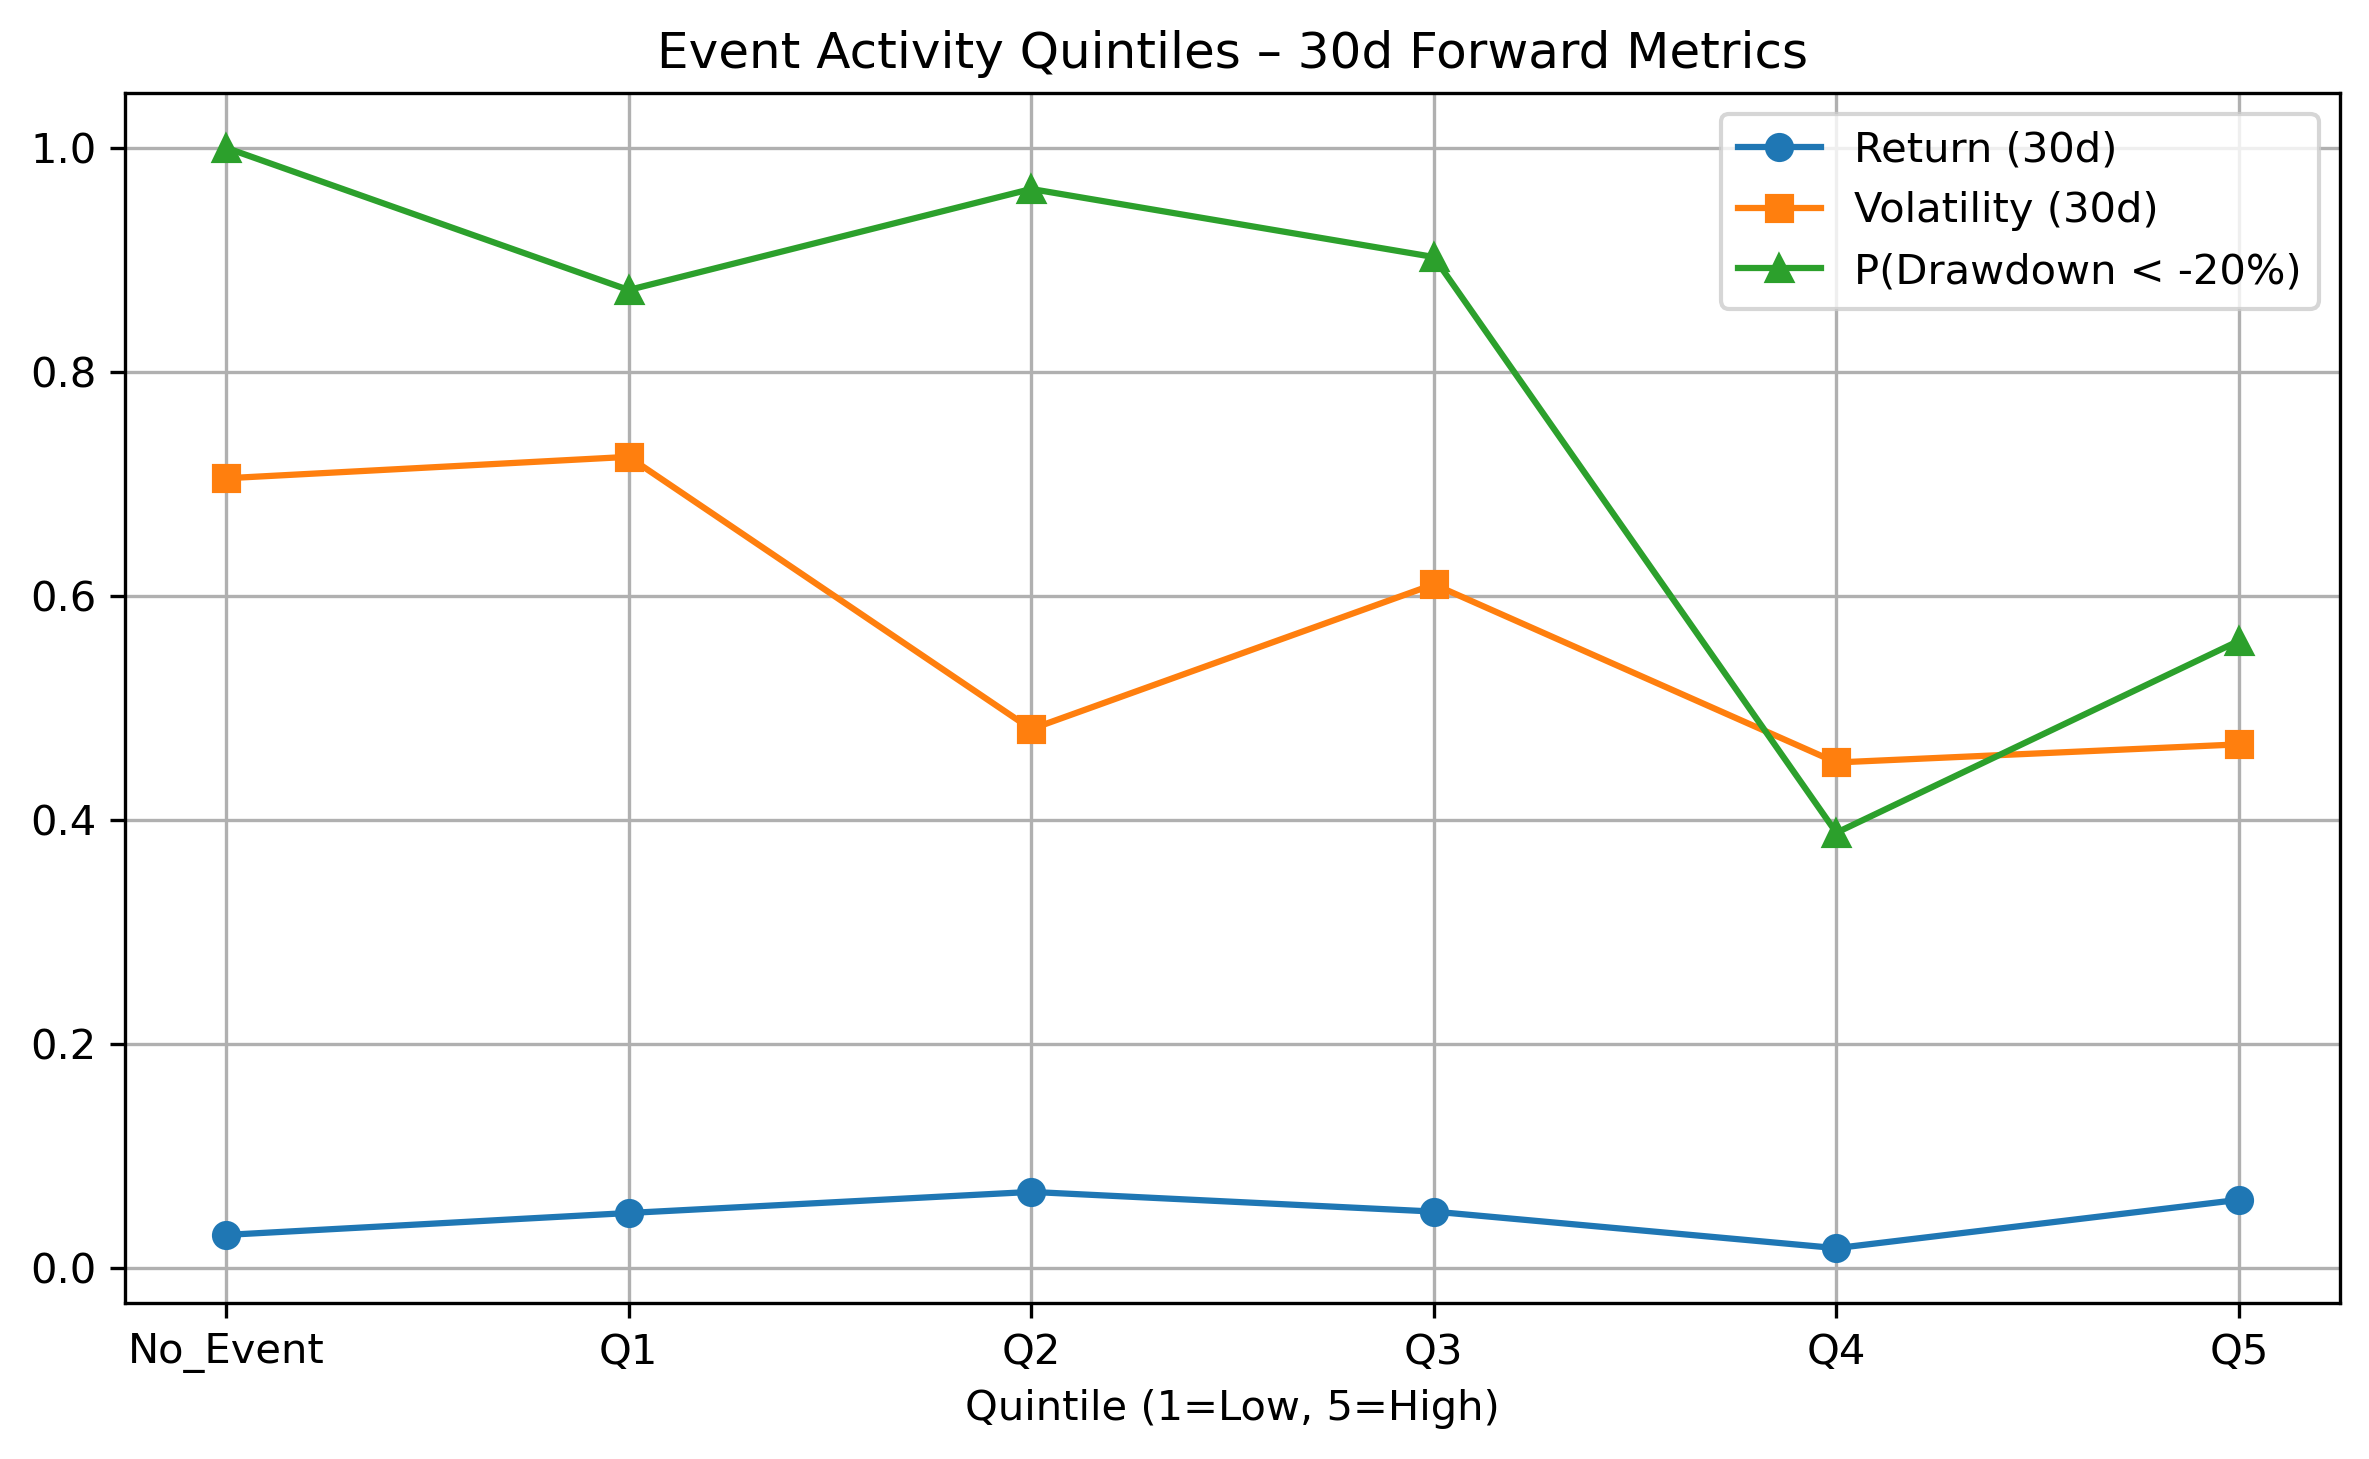

In [17]:
display(Image("plots/event_quintile_forward_metrics.png", width=600))

We further examine whether the constructed risk index aligns with BTC price levels. Higher risk quintiles are generally associated with higher BTC price levels, indicating that elevated risk tends to coincide with richer market regimes rather than undervalued accumulation conditions. Taken together, these results suggest that Polymarket event activity may function more effectively as a risk regime indicator than as a return predictor, potentially reflecting shifts in market attention or information flow rather than generating independent alpha.

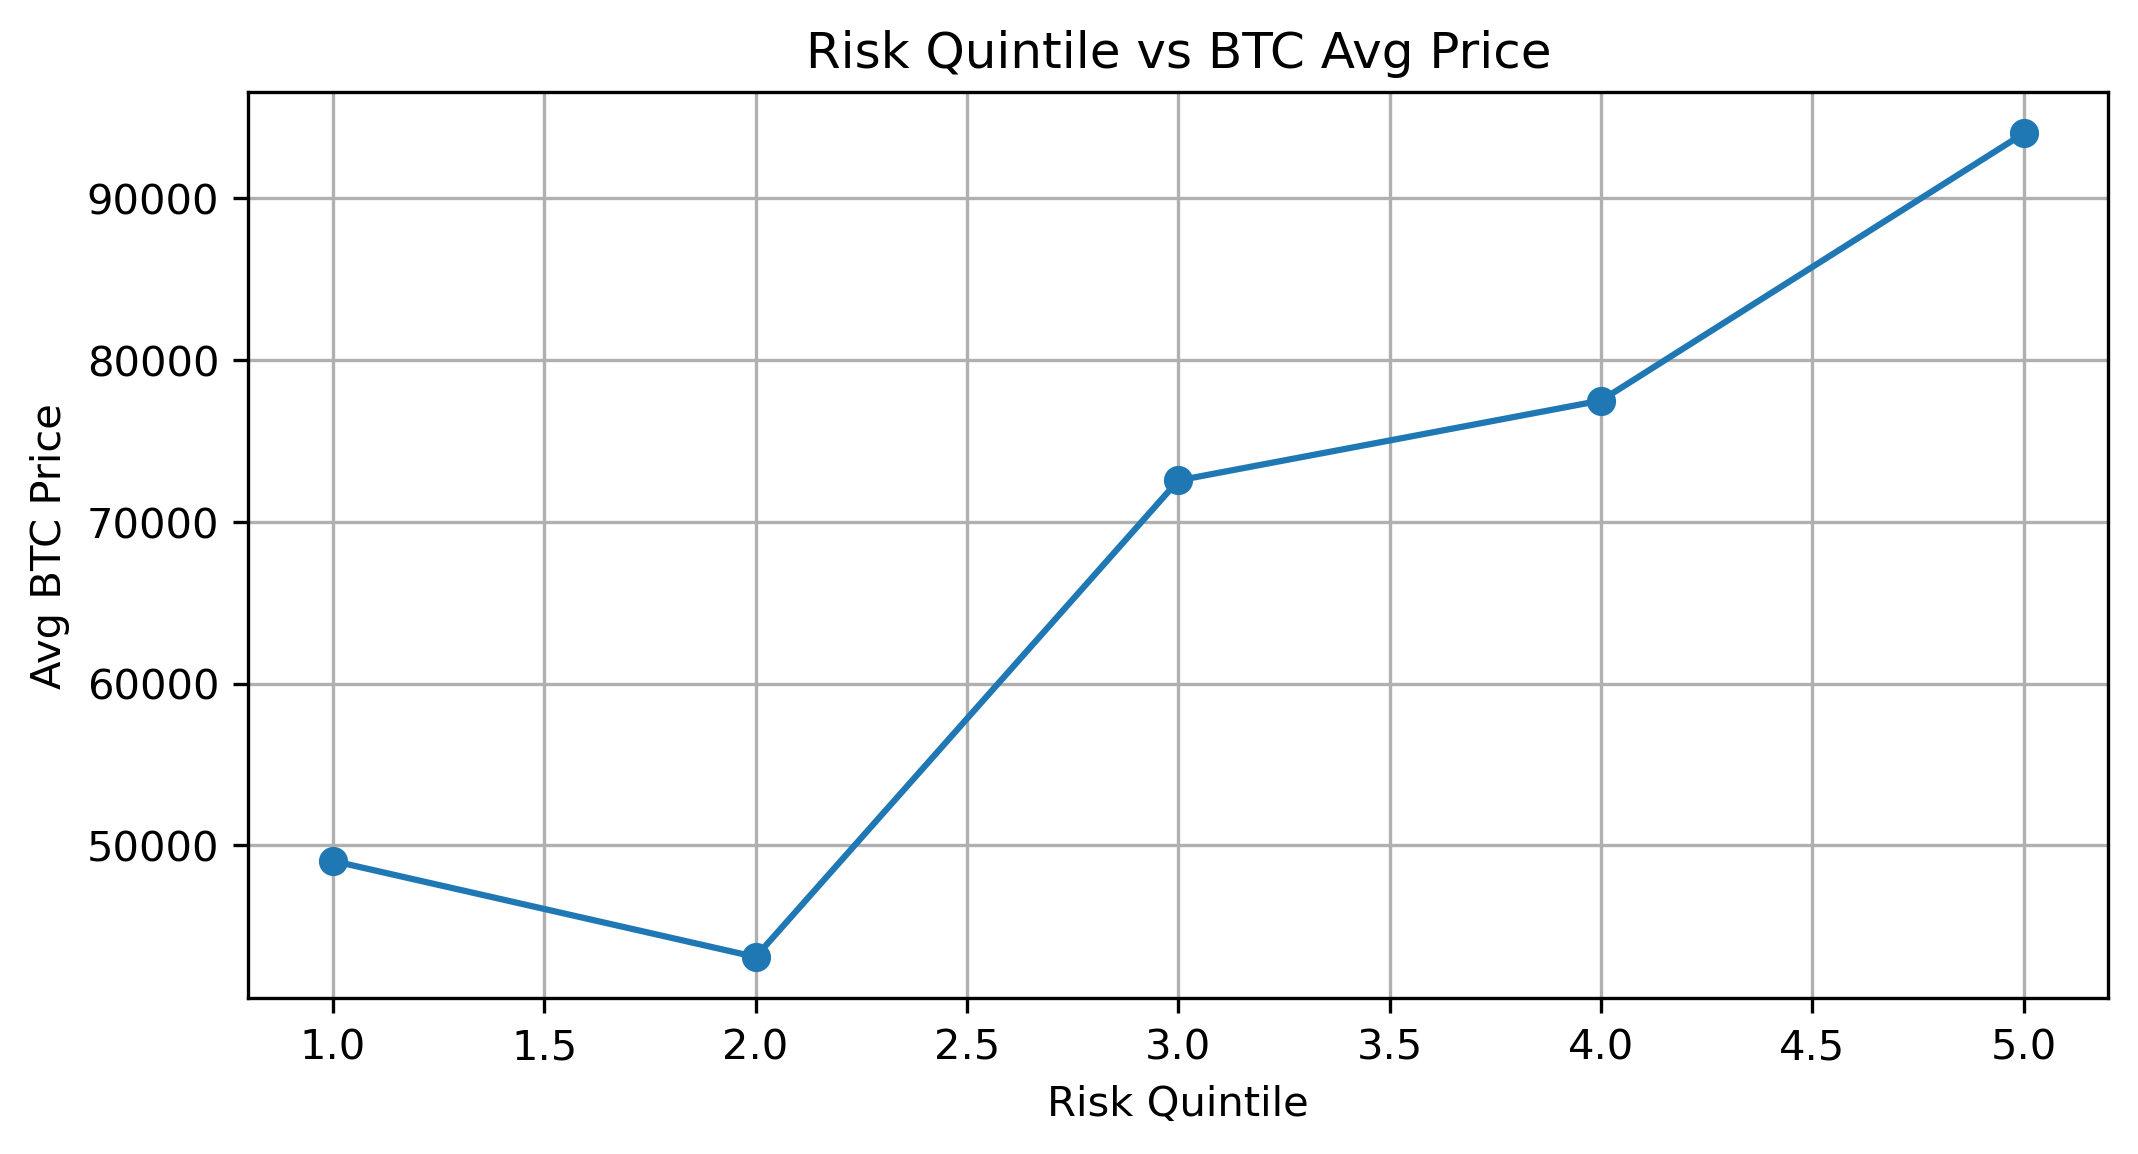

In [18]:
display(Image("plots/Risk_Quintile_vs_BTC_Avg_Price.png", width=600))

4.3 Macro Event Windows and Volatility Behavior

The overlay of Macro Event Windows on the Bitcoin price chart shows: Bitcoin price often trends  toward the predicted outcome of major macro events (e.g., Pro-crypto political shifts).

We've also dsidiscovered a potential recurring pattern where the variance in BTC price narrows as the "Days to Resolution" for a major Polymarket event decreases. Below example using democractic-nominee-2024 resolution

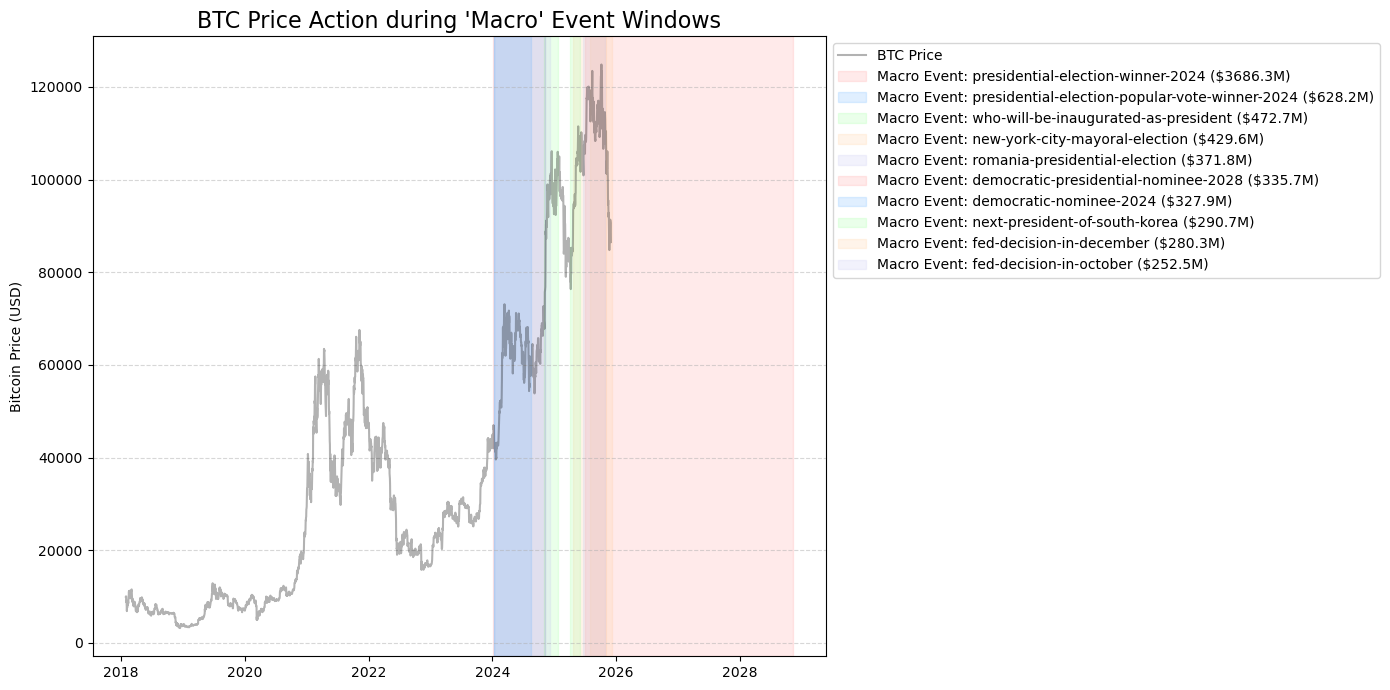

In [10]:
display(Image("plots/BTCPriceMacroWindow.png"))

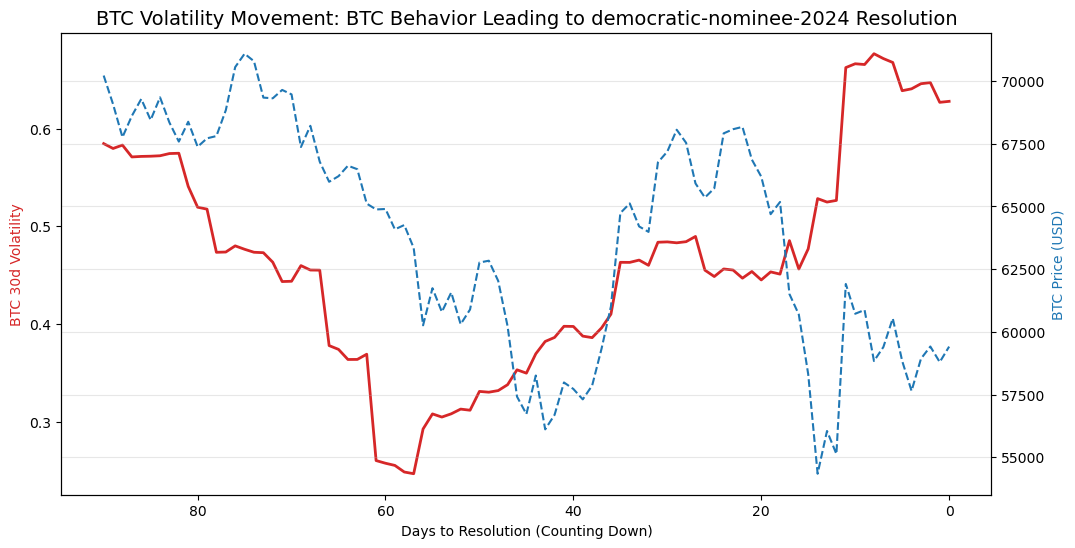

In [12]:
display(Image("plots/BTCVolMovement.png", width=600))

4.4 New Market Creation as an Attention Proxy

The polymarket markets data could potentially acts as a sentiment lead indicator. We observed a spike in new market creation (pm_new_market_count) often precedes surges in BTC activity. 

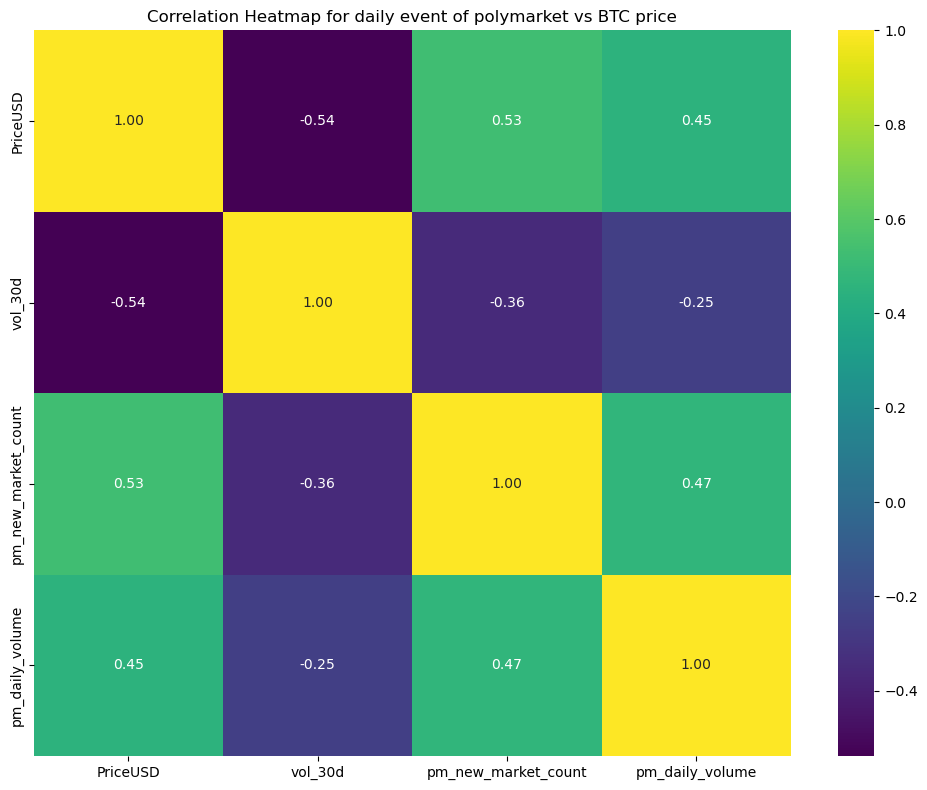

In [11]:
display(Image("plots/PMNewBTC.png", width=600))

4.5 Trade-Level Analysis

On trades data, we try to filter big bets that is > $100,000. Many big trades are executed on high probability outcomes, suggesting potentially large holders use polymarket as a hedging tool for their BTC. We've not successfully discovered a pattern yet but potentially it can act as a lead sginal. Therefore, while the trade-level data is interesting and may contain information about participant behavior, it does not yet provide a stable signal for accumulation timing.

4.6 Conclusion

Overall, our analysis does not show strong evidence that Polymarket improves directional return prediction for Bitcoin. However, Polymarket activity appears to provide useful information about market risk conditions and regime shifts. Event intensity and related risk indicators are more informative for identifying lower-risk accumulation windows than for predicting short-term returns. Therefore, we conclude that Polymarket data may enhance Bitcoin accumulation strategies as a complementary risk filter rather than as a standalone alpha signal, especially when combined with structural on-chain valuation metrics.